In [ ]:
!pip install -U diffusers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.1/516.1 kB 20.9 MB/s eta 0:00:00
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.7.0
    Uninstalling safetensors-0.7.0:
      Successfully uninstalled safetensors-0.7.0
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.37.1
    Uninstalling diffusers-0.37.1:
      Successfully uninstalled diffusers-0.37.1


In [ ]:
pip install -U diffusers transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 24.3 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
from diffusers import StableDiffusionPipeline
import torch

# Load a standard Text-to-Image base model
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

prompt = "Astronaut in a jungle, cold color palette, muted colors, detailed, 8k"
image = pipe(prompt).images[0]
image.show()

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
!pip install diffusers transformers accelerate

In [ ]:
!pip install diffusers transformers accelerate controlnet_aux opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 23.4 MB/s eta 0:00:00


In [ ]:
from controlnet_aux import NormalBaeDetector

# --- Condition 3: Extract Normal Map ---
# NormalBaeDetector estimates 3D surface topology from a 2D monocular image
# It is highly recommended over standard depth-to-normal conversions for ControlNet

print("Loading Normal map estimator...")
normal_detector = NormalBaeDetector.from_pretrained("lllyasviel/Annotators")

# The detector expects a PIL Image and returns a PIL Image
# We pass the clean, original PIL image to maintain mathematical precision
normal_condition = normal_detector(raw_pil_image)
normal_condition = normal_condition.resize((512, 512))

print("Normal map extraction complete!")

/usr/local/lib/python3.12/dist-packages/controlnet_aux/mediapipe_face/mediapipe_face_common.py:7: UserWarning: The module 'mediapipe' is not installed. The package will have limited functionality. Please install it using the command: pip install 'mediapipe'
  warnings.warn(


Loading Normal map estimator...


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/controlnet_aux/segment_anything/modeling/tiny_vit_sam.py:654: UserWarning: Overwriting tiny_vit_5m_224 in registry with controlnet_aux.segment_anything.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/usr/local/lib/python3.12/dist-packages/controlnet_aux/segment_anything/mode

scannet.pt:   0%|          | 0.00/291M [00:00<?, ?B/s]

Loading base model ()...Done.
Removing last two layers (global_pool & classifier).
Normal map extraction complete!


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Executing ControlNet structural generation...


  0%|          | 0/30 [00:00<?, ?it/s]

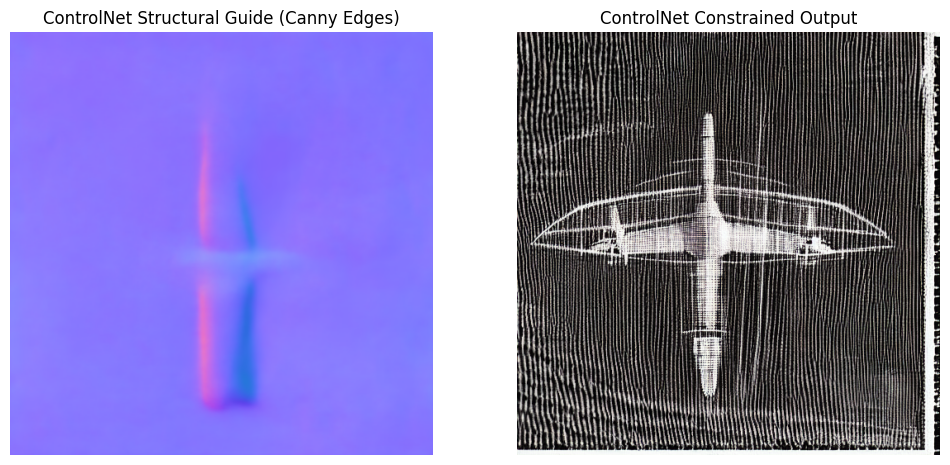

In [ ]:
import torch
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UniPCMultistepScheduler

# 1. Load the specific ControlNet model trained for Canny Edges
controlnet_id = "lllyasviel/sd-controlnet-canny"
controlnet = ControlNetModel.from_pretrained(controlnet_id, torch_dtype=torch.float16)

# 2. Load the base Stable Diffusion pipeline embedded with our ControlNet
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    model_id,
    controlnet=controlnet,
    torch_dtype=torch.float16
).to("cuda")

# 3. Swap out the default scheduler for a faster, modern one (UniPC)
pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)

# 4. Define your creative prompt.
# Notice how drastically we are changing the style, yet the geometry will hold.
prompt = "An unclear sonar scan of crashed aircraft in the seabed surrounded by small broken parts in black and white."
negative_prompt = "8k, clear, color, daytime, bright sun, grass, trees, buildings"

print("Executing ControlNet structural generation...")
conditioning_image = normal_condition
# 5. Run generation
# controlnet_conditioning_scale=1.0 means force strict adherence to the edge map
output_image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=conditioning_image,
    controlnet_conditioning_scale=1.0,
    num_inference_steps=30,
    guidance_scale=7.5
).images[0]

# 6. Save and display the result side-by-side with the structural guide
output_image.save("controlnet_output.png")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(conditioning_image)
axes[0].set_title("ControlNet Structural Guide (Canny Edges)")
axes[0].axis("off")

axes[1].imshow(output_image)
axes[1].set_title("ControlNet Constrained Output")
axes[1].axis("off")
plt.show()

In [ ]:
pip install controlnet_aux

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 10.9 MB/s eta 0:00:00


In [ ]:
import cv2
import numpy as np
import torch
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForSemanticSegmentation

# 1. Load baseline image as a clean PIL Image object
img_path = "/content/1.jpg"
raw_pil_image = Image.open(img_path).convert("RGB").resize((512, 512))

# --- Condition 1: Extract Semantic Segmentation Map FIRST ---
# (We pass the clean PIL image directly to avoid channel dimension errors)
processor = AutoImageProcessor.from_pretrained("nvidia/segformer-b0-finetuned-ade-512-512")
segmenter = AutoModelForSemanticSegmentation.from_pretrained("nvidia/segformer-b0-finetuned-ade-512-512")

inputs = processor(images=raw_pil_image, return_tensors="pt")
with torch.no_grad():
    outputs = segmenter(**inputs)

# Convert segment outputs to a color-coded layout map
arg_segmentation = torch.argmax(outputs.logits, dim=1)[0]
color_seg = np.zeros((arg_segmentation.shape[0], arg_segmentation.shape[1], 3), dtype=np.uint8)

# Apply a standard color palette to distinguish object categories
palette = np.array([[120, 120, 120], [180, 120, 120], [6, 230, 230], [80, 50, 50], [4, 200, 3]])
for label, color in enumerate(palette):
    color_seg[arg_segmentation == label] = color

seg_condition = Image.fromarray(color_seg).resize((512, 512))


# --- Condition 2: Extract Canny Edges SECOND ---
# Now we convert the PIL image to a numpy array safely for OpenCV
image_np = np.array(raw_pil_image)
canny_edges = cv2.Canny(image_np, 100, 200)

# Duplicate the single grayscale channel into 3 channels (RGB) for ControlNet
canny_edges = np.stack([canny_edges] * 3, axis=-1)
canny_condition = Image.fromarray(canny_edges)

print("Structural extraction complete!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
The image processor of type `SegformerImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Structural extraction complete!


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Token indices sequence length is longer than the specified maximum sequence length for this model (179 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['black , sharp - edged acoustic shadow is cast directly to the right of the entire aircraft structure , extending slightly longer and at a lower angle than the original capture to simulate a modified towfi

Executing ControlNet structural generation...


  0%|          | 0/30 [00:00<?, ?it/s]

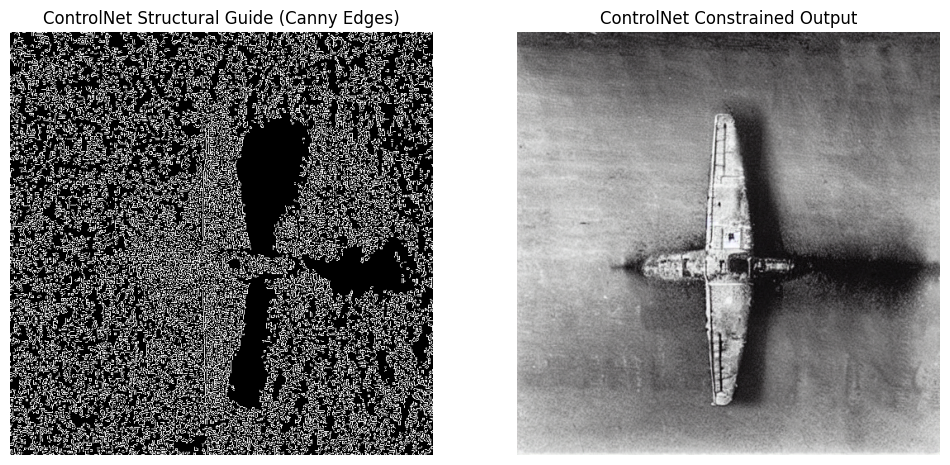

In [ ]:
import torch
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UniPCMultistepScheduler

# 1. Load the specific ControlNet model trained for Canny Edges
controlnet_id = "lllyasviel/sd-controlnet-canny"
controlnet = ControlNetModel.from_pretrained(controlnet_id, torch_dtype=torch.float16)

# 2. Load the base Stable Diffusion pipeline embedded with our ControlNet
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    model_id,
    controlnet=controlnet,
    torch_dtype=torch.float16
).to("cuda")

# 3. Swap out the default scheduler for a faster, modern one (UniPC)
pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)

# 4. Define your creative prompt.
# Notice how drastically we are changing the style, yet the geometry will hold.
prompt = "A high-definition, authentic monochromatic grayscale side-scan sonar image depicting a submerged twin-engine aircraft wreck, maintaining its central position with the nose pointing towards the left. The aircraft's fuselage, wings, and tail section exhibit high-intensity, bright specular backscatter reflections on the surfaces facing the incoming sonar signal from the left. A deep-black, sharp-edged acoustic shadow is cast directly to the right of the entire aircraft structure, extending slightly longer and at a lower angle than the original capture to simulate a modified towfish altitude. The seabed background departs from uniform noise, featuring a mixture of subtle sand ripples and irregular patches of larger gravel to provide textural variation. To enhance realism, subtle range streaks and water column noise are visible at the near-range left side, alongside a faint, partially buried section of debris near the lower wing."
negative_prompt = "Color, RGB, photorealistic underwater optical photography, sunlight, daylight, blue water, high visibility, clear water, marine life, schools of fish, divers, vibrant colors, smooth textures, low resolution, blurry, out of focus, artistic rendering, cartoon, illustration, bright uniform lighting, optical shadows, incorrect physics, high dynamic range."

print("Executing ControlNet structural generation...")
conditioning_image = canny_condition
# 5. Run generation
# controlnet_conditioning_scale=1.0 means force strict adherence to the edge map
output_image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=conditioning_image,
    controlnet_conditioning_scale=1.0,
    num_inference_steps=30,
    guidance_scale=7.5
).images[0]

# 6. Save and display the result side-by-side with the structural guide
output_image.save("controlnet_output.png")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(conditioning_image)
axes[0].set_title("ControlNet Structural Guide (Canny Edges)")
axes[0].axis("off")

axes[1].imshow(output_image)
axes[1].set_title("ControlNet Constrained Output")
axes[1].axis("off")
plt.show()

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Running Multi-ControlNet processing loop...


  0%|          | 0/30 [00:00<?, ?it/s]

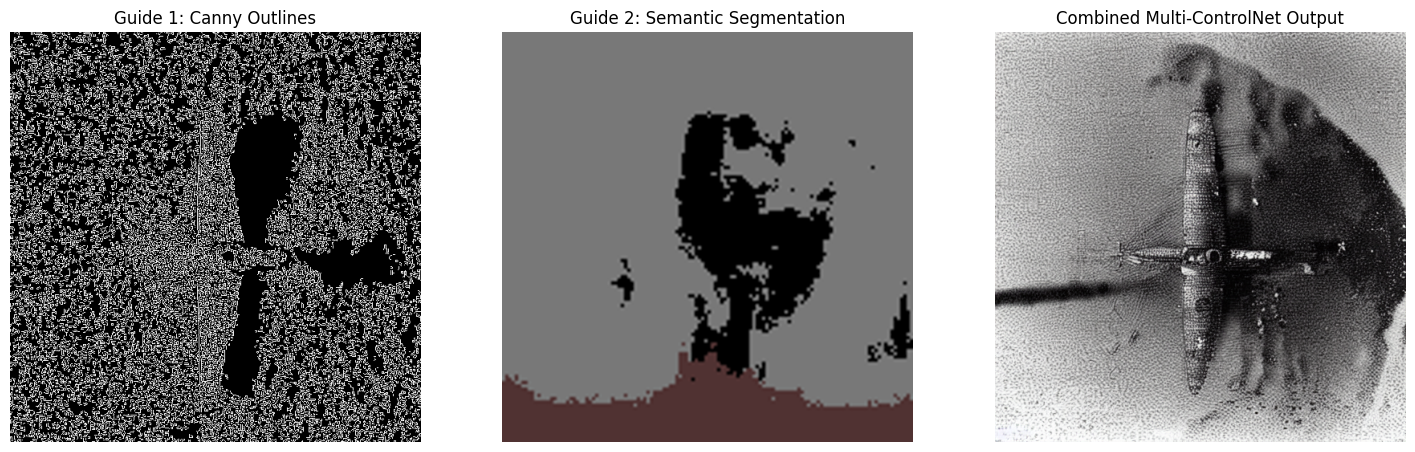

In [ ]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UniPCMultistepScheduler

# 1. Load both ControlNet structural models as a Python list
controlnet_models = [
    ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-seg", torch_dtype=torch.float16),
    ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-canny", torch_dtype=torch.float16)
]

# 2. Build the unified pipeline
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    model_id,
    controlnet=controlnet_models, # Passing the list here activates Multi-ControlNet
    torch_dtype=torch.float16
).to("cuda")

pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)

# 3. Define prompt variables
prompt = "An unclear sonar scan of a newer crashed aircraft in the seabed surrounded by small broken parts in black and white."
negative_prompt = "8k, clear, color, daytime, bright sun, grass, trees, buildings"

# 4. Define conditioning weights
# 1.0 means full structural enforcement. You can tweak this list, e.g., [0.6, 1.0]
# if you want the model to follow the roads loosely but match the sharp edges strictly.
conditioning_scales = [1.0, 1.0]

print("Running Multi-ControlNet processing loop...")
output_image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=[seg_condition, canny_condition], # Must match the order of your controlnet_models list
    controlnet_conditioning_scale=conditioning_scales,
    num_inference_steps=30,
    guidance_scale=8.0
).images[0]

# 5. Display the multi-guide pipeline outputs side-by-side
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(canny_condition)
axes[0].set_title("Guide 1: Canny Outlines")
axes[0].axis("off")

axes[1].imshow(seg_condition)
axes[1].set_title("Guide 2: Semantic Segmentation")
axes[1].axis("off")

axes[2].imshow(output_image)
axes[2].set_title("Combined Multi-ControlNet Output")
axes[2].axis("off")
plt.show()

In [ ]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UniPCMultistepScheduler

# 1. Load both ControlNet structural models as a Python list
controlnet_models = [
    ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-seg", torch_dtype=torch.float16),
    ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-canny", torch_dtype=torch.float16)
]

# 2. Build the unified pipeline
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    model_id,
    controlnet=controlnet_models, # Passing the list here activates Multi-ControlNet
    torch_dtype=torch.float16
).to("cuda")

pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)

# 3. Define prompt variables
prompt = "A high-tech electric highway passing through a neon cyberpunk ecosystem, futuristic, clean style, architectural render, 8k resolution"
negative_prompt = "blurry, low quality, noise, grain, old road, dirt, analog photo"

# 4. Define conditioning weights
# 1.0 means full structural enforcement. You can tweak this list, e.g., [0.6, 1.0]
# if you want the model to follow the roads loosely but match the sharp edges strictly.
conditioning_scales = [1.0, 1.0]

print("Running Multi-ControlNet processing loop...")
output_image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=[seg_condition, canny_condition], # Must match the order of your controlnet_models list
    controlnet_conditioning_scale=conditioning_scales,
    num_inference_steps=30,
    guidance_scale=8.0
).images[0]

# 5. Display the multi-guide pipeline outputs side-by-side
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(canny_condition)
axes[0].set_title("Guide 1: Canny Outlines")
axes[0].axis("off")

axes[1].imshow(seg_condition)
axes[1].set_title("Guide 2: Semantic Segmentation")
axes[1].axis("off")

axes[2].imshow(output_image)
axes[2].set_title("Combined Multi-ControlNet Output")
axes[2].axis("off")
plt.show()

Depth map


In [ ]:
from controlnet_aux import ZoeDetector
import torch
import cv2
import numpy as np
import torch
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForSemanticSegmentation

# 1. Load baseline image as a clean PIL Image object
img_path = "/content/2.jpg"
raw_pil_image = Image.open(img_path).convert("RGB").resize((512, 512))
# --- Condition: Extract Depth Map (Highly Recommended for Sonar) ---
print("Loading ZoeDepth estimator...")

# ZoeDepth provides a more accurate relative volume estimation than standard MiDaS
# We load it using the standard Annotators repository
depth_estimator = ZoeDetector.from_pretrained("lllyasviel/Annotators")

# Pass the clean, original PIL image directly to the estimator
# This extracts the depth gradients representing the aircraft's volume
depth_condition = depth_estimator(raw_pil_image)

# Resize to match the pipeline output resolution
depth_condition = depth_condition.resize((512, 512))

print("Depth map extraction complete!")

# Optional: Save it to inspect the volume gradients before generation
# depth_condition.save("output_depth_condition.png")

Loading ZoeDepth estimator...


ZoeD_M12_N.pt:   0%|          | 0.00/1.44G [00:00<?, ?B/s]

Depth map extraction complete!


In [ ]:
import torch
import numpy as np
from PIL import Image
from diffusers import (
    StableDiffusionControlNetImg2ImgPipeline,
    ControlNetModel,
    EulerAncestralDiscreteScheduler,
)

# 1. Depth ControlNet
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-depth", torch_dtype=torch.float16
)

# 2. Img2Img pipeline
pipe = StableDiffusionControlNetImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16,
    safety_checker=None,          # avoids false positives on grayscale wreck imagery
).to("cuda")

pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)

# 3. Compact prompts (< 77 tokens, no A1111 weighting)
prompt = (
    "grayscale side-scan sonar image, submerged twin-engine aircraft wreck, "
    "top-down, nose pointing left, bright specular highlight on port side, "
    "sharp black acoustic shadow to the right, sandy seabed, ripples, gravel, "
    "monochrome marine survey scan"
)
negative_prompt = (
    "color, RGB, photorealistic, optical photo, daylight, blue water, "
    "marine life, smooth gradients, clean edges, 3d render, illustration, artistic"
)

# 4. Generation — note strength lowered for augmentation
output = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=raw_pil_image,            # base scaffold (the original scan)
    control_image=depth_condition,  # ZoeDepth map = geometric boundary
    strength=0.45,                  # 0.35–0.5 keeps the target recognizable
    controlnet_conditioning_scale=1.0,
    num_inference_steps=30,
    guidance_scale=5.0,
).images[0]

# 5. Grayscale + physically-correct sonar speckle (Rayleigh multiplicative)
def add_sonar_speckle(pil_img, sigma=0.25):
    arr = np.asarray(pil_img.convert("L"), dtype=np.float32) / 255.0
    # multiplicative speckle: I' = I * (1 + n), n ~ N(0, sigma)
    noise = np.random.normal(0.0, sigma, arr.shape)
    out = np.clip(arr * (1.0 + noise), 0.0, 1.0)
    return Image.fromarray((out * 255).astype(np.uint8))

final = add_sonar_speckle(output, sigma=0.25)
final.save("controlnet_img2img_depth_@.png")

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet_img2img.StableDiffusionControlNetImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/13 [00:00<?, ?it/s]